In [36]:
# !pip install numpy scipy matplotlib seaborn scikit-learn mesa==3.0 -q

# Recolección de Alimentos 
*Objetivo del Sistema:* Desarrollar un sistema donde agentes llamados 'exploradores' buscan comida y la llevan de vuelta a su base. Los exploradores se desplazan buscando celdas con alimentos y regresan a la base una vez que encuentran un recurso.

**Características del Sistema:**
* **Energía del Explorador:** Cada explorador comienza con una energía máxima de X unidades, y cada movimiento consume 1 unidad de energía. Al llegar a la base, el explorador recarga completamente su energía.
* **Ubicación de la Base:** La base siempre se encuentra en el centro del área de búsqueda.
* **Parámetros del Sistema:**
    * Un área de NxN celdas.
    * Un número específico de exploradores.
    * Una base fija en una celda determinada.
    * Un número de recursos.
    * Un máximo de energía que los exploradores pueden tener.
* **Distribución de Agentes y Recursos:**
    * Tanto los agentes como los recursos se distribuyen aleatoriamente al inicio de la simulación.
* **Comportamiento por Paso:**
    * Si la celda contiene recursos, el agente los recoge y regresa a la base.
    * Si la celda no contiene recursos, el agente elige una dirección aleatoria para moverse (una de las 4 celdas vecinas) a una celda sin otro agente. Si no puede moverse allí, permanecerá en la misma celda.

In [37]:
# Requiero Mesa > 3.0.3
# Importamos las clases que se requieren para manejar los agentes (Agent) y su entorno (Model).
# Cada modelo puede contener múltiples agentes.
from mesa import Agent, Model

# Debido a que necesitamos que existe un solo agente por celda, elegimos ''SingleGrid''.
from mesa.space import SingleGrid

# Con ''RandomActivation'', hacemos que todos los agentes se activen de forma aleatoria.
from mesa.time import RandomActivation

# Haremos uso de ''DataCollector'' para obtener información de cada paso de la simulación.
from mesa.datacollection import DataCollector

# Haremos uso de ''batch_run'' para ejecutar varias simulaciones
from mesa.batchrunner import batch_run

# matplotlib lo usaremos crear una animación de cada uno de los pasos del modelo.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Importamos los siguientes paquetes para el mejor manejo de valores numéricos.
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

# Definimos otros paquetes que vamos a usar para medir el tiempo de ejecución de nuestro algoritmo.
import time
import datetime

In [38]:
class CollectorAgent(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.energy = self.max_energy = 100
        self.collected_food = 0
        self.carrying_food = False
        self.visited_cells = 1
        self.state = 0 # 0 - exploring, 1 - going to base

    def move(self):
        possible_positions = self.model.grid.get_neighborhood(self.pos, 
            moore=False, include_center=False)
        options = np.random.permutation(len(possible_positions))

        for i in options:
            position = possible_positions[i]
            if self.model.grid.is_cell_empty(position):
                self.model.grid.move_agent(self, position)
                self.visited_cells += 1
                self.energy -= 1
                break

    def exploring(self):
        (x, y) = self.pos
        if self.model.field[x][y] == 1:
            self.model.field[x][y] = 0
            self.collected_food += 1
            self.carrying_food = True
            self.state = 1
        elif self.energy <= self.model.min_energy:
            self.state = 1
        else: 
            self.move()

    def going_to_base(self):
        (x, y) = self.pos
        if self.pos == self.model.coord_base:
            if self.carrying_food:
                self.model.collected_food += 1
            self.energy = self.max_energy
            self.carrying_food = False
            self.visited_cells += 1
            self.state = 0
        else:
            if abs(x - self.model.coord_base[0]) > abs(y - self.model.coord_base[1]):
                if x > self.model.coord_base[0]:
                    x -= 1
                else:
                    x += 1
            else:
                if y > self.model.coord_base[1]:
                    y -= 1
                else: 
                    y += 1

            if self.model.grid.is_cell_empty( (x, y) ):
                self.model.grid.move_agent(self, (x, y))
                self.visited_cells += 1

    def step(self):
        (x, y) = self.pos
        if self.state == 0:
            self.exploring()
        else:
            self.going_to_base()

In [39]:
def get_grid(model):
    grid = np.zeros( (model.grid.width, model.grid.height) )
    for content, (x, y) in model.grid.coord_iter():
        grid[x][y] = model.field[x][y]
        if (x, y) == model.coord_base:
            grid[x][y] = 2
        if content != None:
            grid[x][y] = 3
    return grid

In [40]:
class CollectorModel(Model):
    def __init__(self, width, height, agents=5, resources=20):
        super().__init__()

        self.grid = SingleGrid(width, height, torus=False)
        self.schedule = RandomActivation(self)

        self.coord_base = (width // 2, height // 2)
        self.min_energy = (width // 2) + (height // 2)

        self.collected_food = 0
        self.max_food = resources

        self.field = np.zeros( (width, height) )
        while resources > 0:
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if (x, y) != self.coord_base and self.field[x][y] == 0:
                self.field[x][y] = 1
                resources -= 1
                
        i = 0
        while i < agents:
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if self.grid.is_cell_empty( (x, y) ):
                agent = CollectorAgent(self)
                self.grid.place_agent(agent, (x, y))
                self.schedule.add(agent)
                i += 1

        self.datacollector = DataCollector(model_reporters = {"Grid" : get_grid,
                        "Steps": lambda model : model.steps},
                    agent_reporters = {
                        "Collected": lambda agent : agent.collected_food,
                        "Visited": lambda agent : agent.visited_cells})

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()

    def is_all_clean(self):
        return self.collected_food == self.max_food

In [41]:
WIDTH = 11
HEIGHT = 11
AGENTS = 5
RESOURCES = 20
ITERATIONS = 2000

model = CollectorModel(WIDTH, HEIGHT, AGENTS, RESOURCES)
for i in range(ITERATIONS):
    if model.is_all_clean():
        break
    model.step()
print ("Max steps:", model.steps)

Max steps: 359


/tmp/ipykernel_646/3029642197.py:6: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in a future version. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = RandomActivation(self)


In [42]:
all_grids = model.datacollector.get_model_vars_dataframe()
all_grids.head(5)

,Grid,Steps
0,"[[0.0, 0.0, 0.0, 3.0, 1.0, 1.0, 3.0, 0.0, 1.0,...",1
1,"[[0.0, 0.0, 0.0, 3.0, 1.0, 3.0, 0.0, 0.0, 1.0,...",2
2,"[[0.0, 0.0, 0.0, 0.0, 1.0, 3.0, 0.0, 0.0, 1.0,...",3
3,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...",4
4,"[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...",5


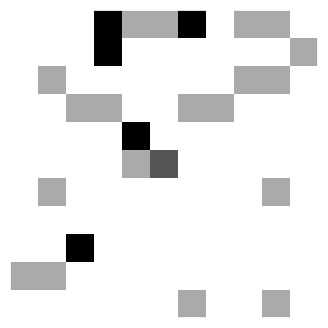

In [43]:
fig, axis = plt.subplots(figsize=(4, 4))
axis.set_xticks([])
axis.set_yticks([])
patch = plt.imshow(all_grids.iloc[0,0], cmap=plt.cm.binary)

def animate(frame):
    patch.set_data(all_grids.iloc[frame, 0])

anim = animation.FuncAnimation(fig, animate, frames=model.steps)

In [44]:
anim

In [45]:
params = {"width":11, "height":11, "agents":5, "resources":20}

ITERATIONS = 500
SIMULATIONS = 10

result = batch_run(
    CollectorModel,
    parameters = params, 
    iterations = SIMULATIONS, 
    max_steps = ITERATIONS,
    number_processes = 1,
    data_collection_period = 1,
    display_progress = True,
)

  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_646/3029642197.py:6: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in a future version. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = RandomActivation(self)


In [46]:
df = pd.DataFrame(result)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25010 entries, 0 to 25009
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   RunId      25010 non-null  int64  
 1   iteration  25010 non-null  int64  
 2   Step       25010 non-null  int64  
 3   width      25010 non-null  int64  
 4   height     25010 non-null  int64  
 5   agents     25010 non-null  int64  
 6   resources  25010 non-null  int64  
 7   Grid       25010 non-null  object 
 8   Steps      25010 non-null  int64  
 9   AgentID    25000 non-null  float64
 10  Collected  25000 non-null  float64
 11  Visited    25000 non-null  float64
dtypes: float64(3), int64(8), object(1)
memory usage: 2.3+ MB


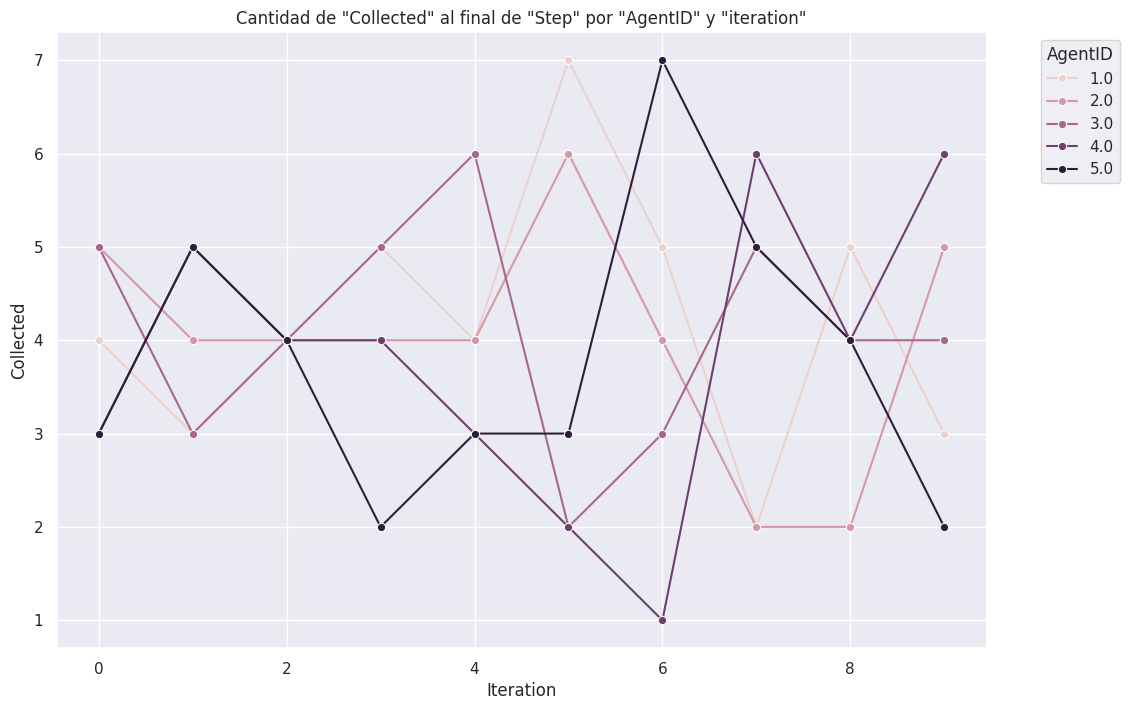

In [47]:
# Supongamos que tu dataframe se llama df
# Filtrar para obtener las últimas entradas de cada "Step" para cada "AgentID"
df_last_step = df.loc[df.groupby(['iteration', 'AgentID'])['Step'].idxmax()]

# Graficar
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_last_step, x='iteration', y='Collected', hue='AgentID', marker='o')

plt.title('Cantidad de "Collected" al final de "Step" por "AgentID" y "iteration"')
plt.xlabel('Iteration')
plt.ylabel('Collected')
plt.legend(title='AgentID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

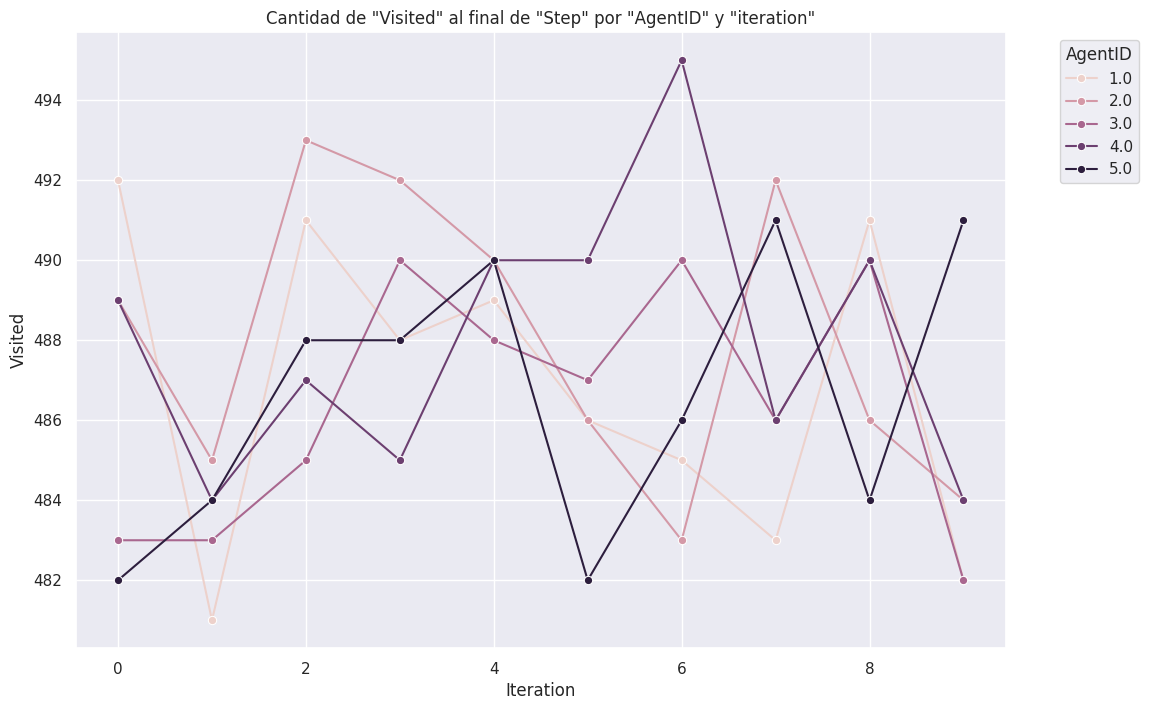

In [48]:
# Supongamos que tu dataframe se llama df
# Filtrar para obtener las últimas entradas de cada "Step" para cada "AgentID"
df_last_step = df.loc[df.groupby(['iteration', 'AgentID'])['Step'].idxmax()]

# Graficar
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_last_step, x='iteration', y='Visited', hue='AgentID', marker='o')

plt.title('Cantidad de "Visited" al final de "Step" por "AgentID" y "iteration"')
plt.xlabel('Iteration')
plt.ylabel('Visited')
plt.legend(title='AgentID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()